####  DECISION TREE & COMPARING WITH LOGISTIC REGRESSION


In [1]:


import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load train/test data
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

feature_columns = X_train.columns.tolist()

In [2]:

#  Training Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree trained!")
print(f"\nDecision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Toss Lost', 'Toss Won']))



Decision Tree trained!

Decision Tree Accuracy: 0.9934

Classification Report:
              precision    recall  f1-score   support

   Toss Lost       0.99      1.00      0.99        72
    Toss Won       1.00      0.99      0.99        79

    accuracy                           0.99       151
   macro avg       0.99      0.99      0.99       151
weighted avg       0.99      0.99      0.99       151



In [3]:

# showing the features the tree felt important
importances = pd.Series(dt_model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

print("\nFeature Importances (higher = more useful for prediction):")
print(importances)




Feature Importances (higher = more useful for prediction):
toss_decision_enc    0.903514
win_by_runs          0.065868
dl_applied           0.014022
win_by_wickets       0.011852
match_month          0.004743
dtype: float64


In [4]:

# Train Logistic Regression for comparison
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)



In [7]:

# Comparing both models
print("\n MODEL COMPARISON")
print(f"{'Model':<25} {'Accuracy':>10}")
print(f"{'Logistic Regression':<25} {accuracy_score(y_test, y_pred_lr):>10.4f}")
print(f"{'Decision Tree':<25} {accuracy_score(y_test, y_pred_dt):>10.4f}")



 MODEL COMPARISON
Model                       Accuracy
Logistic Regression           0.5497
Decision Tree                 0.9934


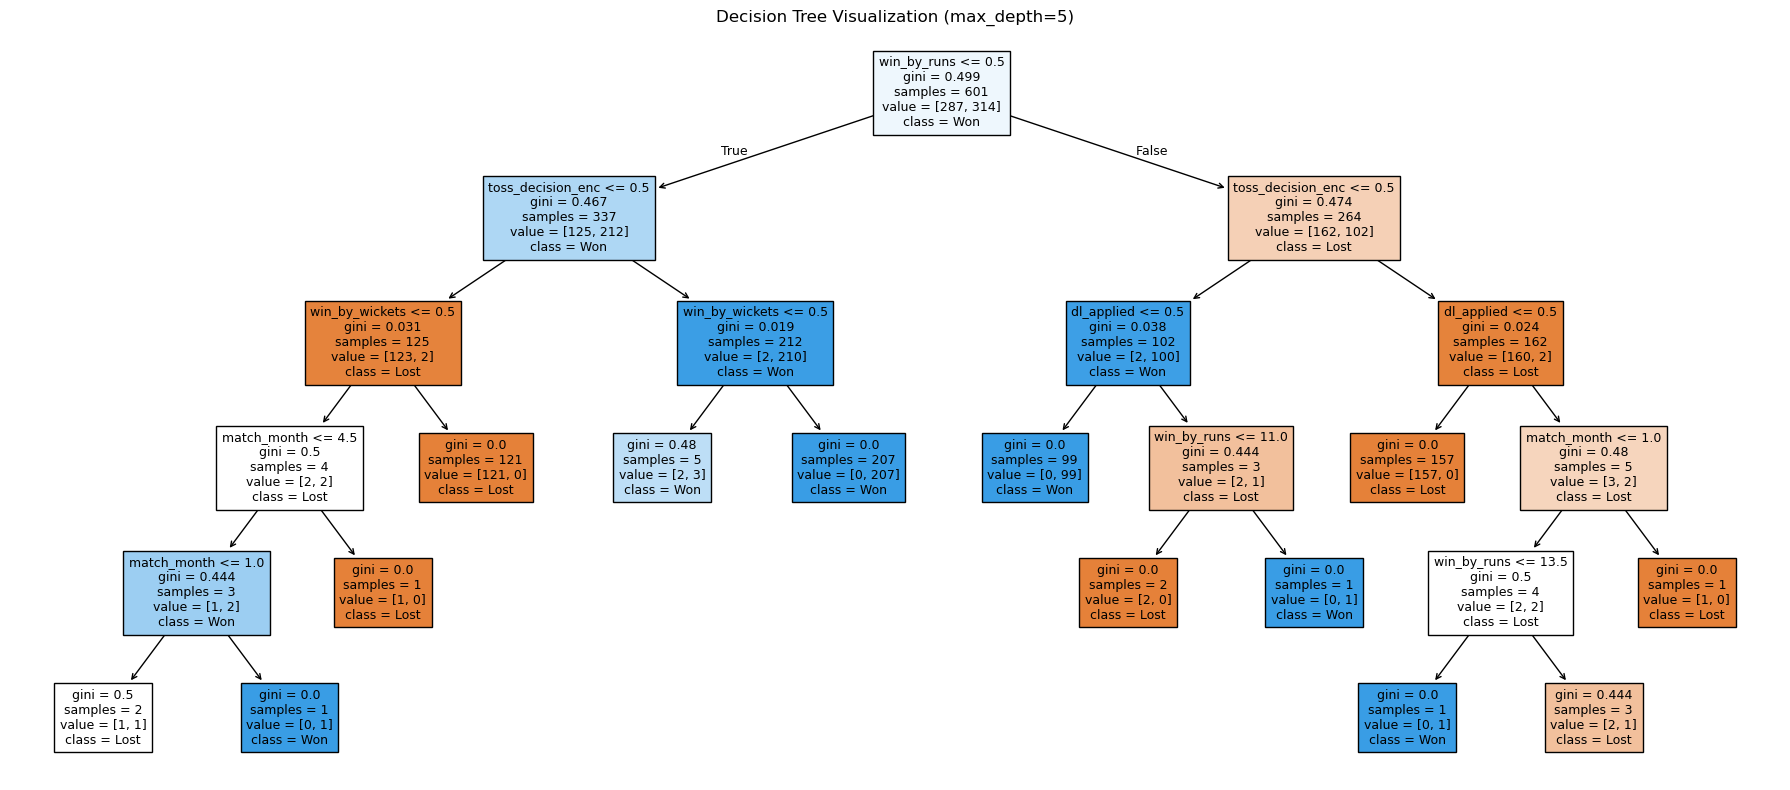

Decision tree diagram saved as 'ipl_decision_tree.png'


In [8]:


# Visualizing the Decision Tree

plt.figure(figsize=(18, 8))
plot_tree(dt_model,
          feature_names=feature_columns,
          class_names=['Lost', 'Won'],
          filled=True,
          fontsize=9)
plt.title('Decision Tree Visualization (max_depth=5)')
plt.tight_layout()
plt.savefig('ipl_decision_tree.png', dpi=150)
plt.show()
print("Decision tree diagram saved as 'ipl_decision_tree.png'")